In [37]:
# ==========================================================
# station datasets + standard cleaning
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILES = {
    18758: r"C:\Users\Gahigi\Desktop\data logger Analysis\18759-datalogger_decoded.csv",
    18759: r"C:\Users\Gahigi\Desktop\data logger Analysis\18760-datalogger_decoded.csv",
    18760: r"C:\Users\Gahigi\Desktop\data logger Analysis\18761-datalogger_decoded.csv",
    18761: r"C:\Users\Gahigi\Desktop\data logger Analysis\18763-datalogger_decoded.csv",
    18762: r"C:\Users\Gahigi\Desktop\data logger Analysis\18762-Revised_datalogger_decode.csv",
    18763: r"C:\Users\Gahigi\Desktop\data logger Analysis\18758-datalogger_decoded.csv",
    18764: r"C:\Users\Gahigi\Desktop\data logger Analysis\18764-Revised_datalogger_decode.csv"
}

KEY_COLS = [
    "Temperature,Average", "Temperature,Minimum", "Temperature,Maximum",
    "Humidity,Avarage", "Humidity,Minimum", "Humidity,Maximum",
    "Wind Speed,Average", "Wind Speed,Minimum", "Wind Speed,Maximum",
    "Precipitation,Accumulation",
    "Global solar radiation,Average",   # may be missing for some stations (e.g., 18763)
]

def load_and_clean(path):
    df = pd.read_csv(path)

    # parse datetime
    df["datetime"] = pd.to_datetime(df["datetime"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")

    # drop fully missing columns + UNKNOWN_*
    miss = df.isna().mean()
    cols_all_missing = miss[miss == 1.0].index.tolist()
    cols_unknown = [c for c in df.columns if str(c).startswith("UNKNOWN_")]
    df = df.drop(columns=sorted(set(cols_all_missing + cols_unknown)), errors="ignore")

    return df

stations = {sid: load_and_clean(p) for sid, p in FILES.items()}

print("Details of the respective datasets used for each station:")
for sid, d in stations.items():
    print(sid, d.shape, "from", d.index.min(), "to", d.index.max())

Details of the respective datasets used for each station:
18758 (29848, 36) from 2023-08-07 16:00:00 to 2025-12-21 10:50:00
18759 (103745, 24) from 2023-08-07 16:00:00 to 2026-02-16 15:10:00
18760 (86002, 21) from 2023-08-07 16:00:00 to 2026-02-16 14:00:00
18761 (19252, 18) from 2023-08-12 16:00:00 to 2026-02-16 15:00:00
18762 (73687, 21) from 2023-08-07 16:00:00 to 2026-02-16 15:10:00
18763 (98864, 27) from 2023-02-28 17:00:00 to 2026-02-16 15:20:00
18764 (82793, 21) from 2023-08-07 16:00:00 to 2025-11-14 21:10:00


In [2]:
# ==========================================================
# CELL 2 — Build a common analysis table (dfk) per station
# ==========================================================
def get_dfk(df):
    cols = [c for c in KEY_COLS if c in df.columns]
    return df[cols].copy()

stations_k = {sid: get_dfk(df) for sid, df in stations.items()}

# variable availability matrix (nice for report)
all_vars = KEY_COLS
avail = pd.DataFrame({sid: [v in stations_k[sid].columns for v in all_vars] for sid in stations_k},
                     index=all_vars)
avail.index.name = "variable"
display(avail)

,18758,18759,18760,18761,18762,18763,18764
variable,,,,,,,
"Temperature,Average",True,True,True,True,True,True,True
"Temperature,Minimum",True,True,True,True,True,True,True
"Temperature,Maximum",True,True,True,True,True,True,True
"Humidity,Avarage",True,True,True,True,True,True,True
"Humidity,Minimum",True,True,True,True,True,True,True
"Humidity,Maximum",True,True,True,True,True,True,True
"Wind Speed,Average",True,True,True,True,True,True,True
"Wind Speed,Minimum",True,True,True,True,True,True,True
"Wind Speed,Maximum",True,True,True,True,True,True,True


# Analysis 1: Completeness (missingness) comparison + visualization

,18758,18759,18760,18761,18762,18763,18764
"Global solar radiation,Average",0.830608,0.999990,0.999942,0.000000,0.999946,0.999929,0.000024
"Humidity,Avarage",1.000000,1.000000,0.999988,1.000000,1.000000,0.999960,1.000000
"Humidity,Maximum",1.000000,1.000000,0.999953,1.000000,1.000000,0.999949,1.000000
"Humidity,Minimum",1.000000,1.000000,0.999953,1.000000,1.000000,0.999960,1.000000
"Precipitation,Accumulation",0.999832,1.000000,0.999919,0.999117,0.999986,0.999960,0.999976
"Temperature,Average",1.000000,0.980934,0.999988,1.000000,1.000000,0.999181,1.000000
"Temperature,Maximum",1.000000,0.980934,0.999977,1.000000,1.000000,0.999160,1.000000
"Temperature,Minimum",1.000000,0.980934,0.999977,1.000000,1.000000,0.999171,1.000000
"Wind Speed,Average",1.000000,1.000000,0.999977,1.000000,1.000000,0.999960,0.435580
"Wind Speed,Maximum",1.000000,1.000000,0.999953,1.000000,0.999986,0.999949,0.435580


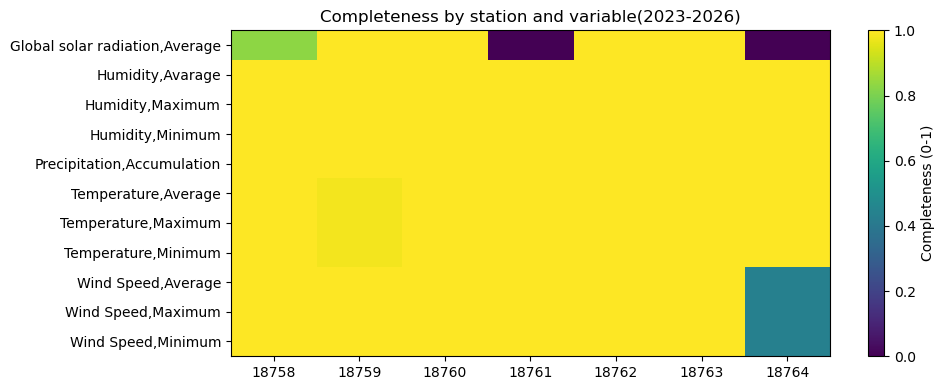

Average completeness ranking:


,avg_completeness
18762,0.999993
18760,0.999962
18761,0.999912
18763,0.999740
18759,0.994799
18758,0.984586
18764,0.755158


In [3]:
# ==========================================================
# CELL 3 — Analysis 1: completeness per station (and heatmap-like plot)
# ==========================================================
completeness = pd.DataFrame(
    {sid: (1 - df.isna().mean()) for sid, df in stations_k.items()}
).fillna(0)

display(completeness)

# Visualization (matrix image)
plt.figure(figsize=(10, 4))
plt.imshow(completeness.values, aspect="auto")
plt.yticks(range(len(completeness.index)), completeness.index)
plt.xticks(range(len(completeness.columns)), completeness.columns, rotation=0)
plt.colorbar(label="Completeness (0-1)")
plt.title("Completeness by station and variable(2023-2026)")
plt.tight_layout()
plt.show()

# Quick ranking by average completeness (common vars)
avg_comp = completeness.replace(0, np.nan).mean().sort_values(ascending=False)
print("Average completeness ranking:")
display(avg_comp.to_frame("avg_completeness"))

#### “The completeness analysis indicates that the majority of stations maintain near-continuous data availability (>99%) across the common meteorological variables

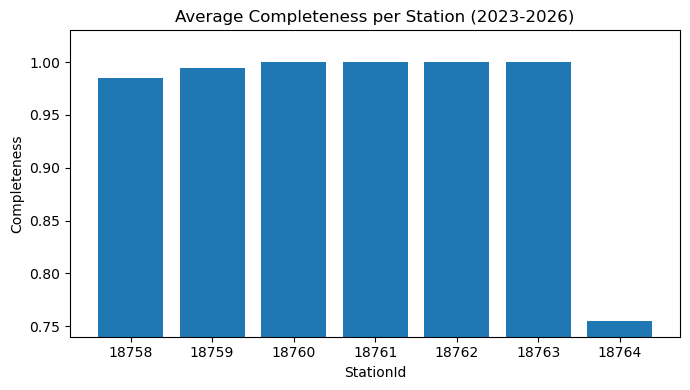

In [4]:
avg_comp = completeness.replace(0, np.nan).mean()

plt.figure(figsize=(7,4))
plt.bar(avg_comp.index.astype(str), avg_comp.values)
plt.title("Average Completeness per Station (2023-2026)")
plt.xlabel("StationId")
plt.ylabel("Completeness")
plt.ylim(0.74, 1.03)  # zoom for clarity
plt.tight_layout()
plt.show()

# variable focused-plot

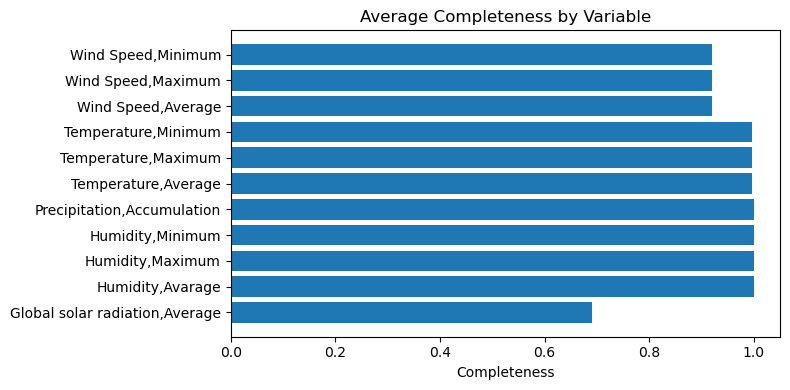

In [38]:
var_comp = completeness.mean(axis=1)

plt.figure(figsize=(8,4))
plt.barh(var_comp.index, var_comp.values)
plt.title("Average Completeness by Variable")
plt.xlabel("Completeness")
plt.tight_layout()
plt.show()

# Heatmap with numbers

In [39]:
"""Completeness=1−
100
5
	​

=0.95

✅ 1.00 → perfect (no missing)
⚠️ 0.80 → some missing
🚨 < 0.70 → serious data loss"""

'Completeness=1−\n100\n5\n\t\u200b\n\n=0.95\n\n✅ 1.00 → perfect (no missing)\n⚠️ 0.80 → some missing\n🚨 < 0.70 → serious data loss'

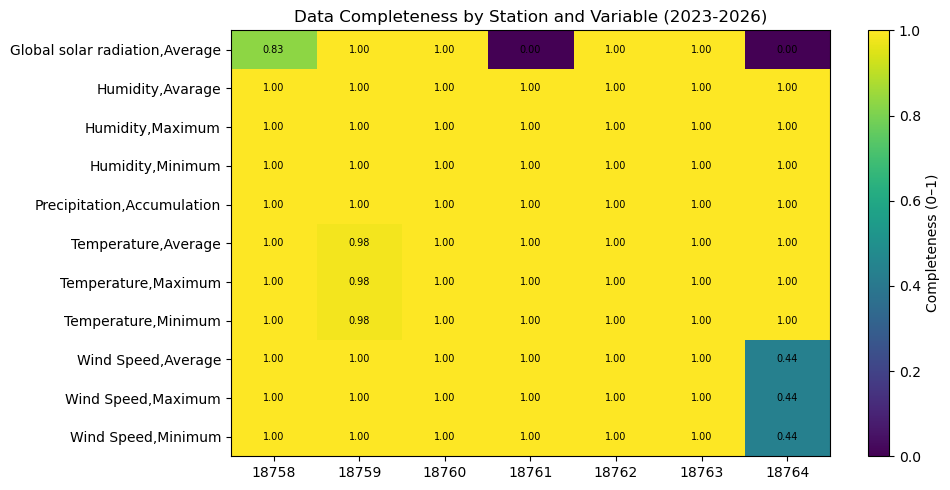

In [6]:
plt.figure(figsize=(10,5))

plt.imshow(completeness.values, aspect="auto")

# axis labels
plt.yticks(range(len(completeness.index)), completeness.index)
plt.xticks(range(len(completeness.columns)), completeness.columns)

# add numbers inside cells (VERY PROFESSIONAL)
for i in range(completeness.shape[0]):
    for j in range(completeness.shape[1]):
        val = completeness.values[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(label="Completeness (0–1)")
plt.title("Data Completeness by Station and Variable (2023-2026)")
plt.tight_layout()
plt.show()

# Out of range checks and ordering violations checks

# Violation rate	  Meaning
### 0%:	                Perfect
### <1%:	               Minor noise
### 1–5%:	           investigate
### >10%:	           serious problem

,StationId,records,out_of_range_count,out_of_range_rate,temp_order_violation_rate,rh_order_violation_rate
0,18758,29848,125,0.004188,0.000000,0.000000
1,18759,103745,2298,0.022150,0.349790,0.000665
2,18760,86002,17168,0.199623,0.044162,0.000174
3,18761,19252,0,0.000000,0.000000,0.000000
4,18762,73687,221,0.002999,0.163964,0.000000
5,18763,98864,549,0.005553,0.149549,0.000051
6,18764,82793,0,0.000000,0.435484,0.004735


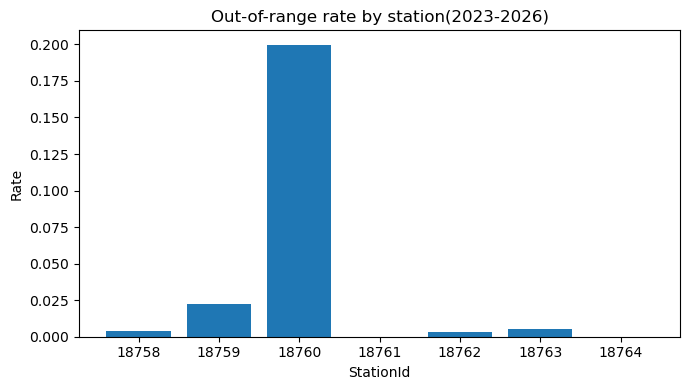

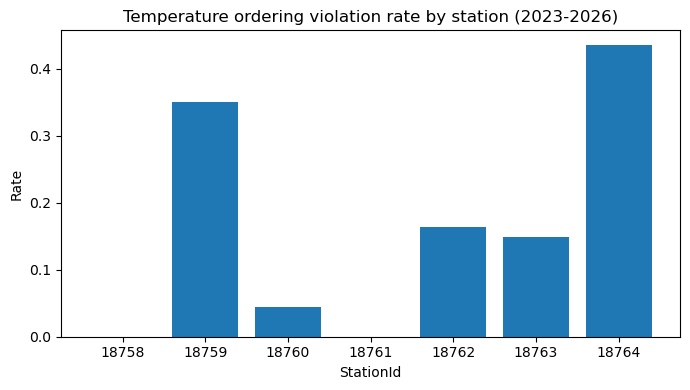

Saved: network_out_of_range_details.csv (exact dates + values)


In [7]:
# ==========================================================
# CELL 4 — Analysis 2: QC violations (out-of-range + ordering)
# ==========================================================
RULES = {
    "Temperature,Average": (-10, 45),
    "Temperature,Minimum": (-10, 45),
    "Temperature,Maximum": (-10, 45),

    "Humidity,Avarage": (0, 100),
    "Humidity,Minimum": (0, 100),
    "Humidity,Maximum": (0, 100),

    "Wind Speed,Average": (0, 60),
    "Wind Speed,Minimum": (0, 60),
    "Wind Speed,Maximum": (0, 60),

    "Precipitation,Accumulation": (0, 500),
    "Global solar radiation,Average": (0, 1400),
}

qc_summary_rows = []
oor_details = []   # detailed out-of-range rows for export if you want

for sid, dfk in stations_k.items():
    n = len(dfk)
    oor_count = 0

    # out-of-range
    for col, (lo, hi) in RULES.items():
        if col in dfk.columns:
            mask = (dfk[col] < lo) | (dfk[col] > hi)
            cnt = int(mask.sum())
            oor_count += cnt

            if cnt > 0:
                tmp = dfk.loc[mask, [col]].rename(columns={col: "value"}).reset_index()
                tmp["StationId"] = sid
                tmp["variable"] = col
                tmp["low"] = lo
                tmp["high"] = hi
                tmp["direction"] = np.where(tmp["value"] < lo, "below_low", "above_high")
                oor_details.append(tmp)

    oor_rate = oor_count / n if n else np.nan

    # ordering violations
    temp_order_rate = np.nan
    if all(c in dfk.columns for c in ["Temperature,Minimum","Temperature,Average","Temperature,Maximum"]):
        ok = (dfk["Temperature,Minimum"] <= dfk["Temperature,Average"]) & (dfk["Temperature,Average"] <= dfk["Temperature,Maximum"])
        temp_order_rate = float((~ok).mean())

    rh_order_rate = np.nan
    if all(c in dfk.columns for c in ["Humidity,Minimum","Humidity,Avarage","Humidity,Maximum"]):
        ok = (dfk["Humidity,Minimum"] <= dfk["Humidity,Avarage"]) & (dfk["Humidity,Avarage"] <= dfk["Humidity,Maximum"])
        rh_order_rate = float((~ok).mean())

    qc_summary_rows.append([sid, n, oor_count, oor_rate, temp_order_rate, rh_order_rate])

qc_summary = pd.DataFrame(
    qc_summary_rows,
    columns=["StationId","records","out_of_range_count","out_of_range_rate","temp_order_violation_rate","rh_order_violation_rate"]
).sort_values("StationId")

display(qc_summary)

# Bar charts (presentation-ready)
plt.figure(figsize=(7,4))
plt.bar(qc_summary["StationId"].astype(str), qc_summary["out_of_range_rate"])
plt.title("Out-of-range rate by station(2023-2026)")
plt.xlabel("StationId")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.bar(qc_summary["StationId"].astype(str), qc_summary["temp_order_violation_rate"].fillna(0))
plt.title("Temperature ordering violation rate by station (2023-2026)")
plt.xlabel("StationId")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

# Optional: export exact out-of-range rows
if len(oor_details):
    oor_df = pd.concat(oor_details, ignore_index=True)
    oor_df.to_csv("network_out_of_range_details.csv", index=False)
    print("Saved: network_out_of_range_details.csv (exact dates + values)")
else:
    print("No out-of-range values found under current thresholds.")

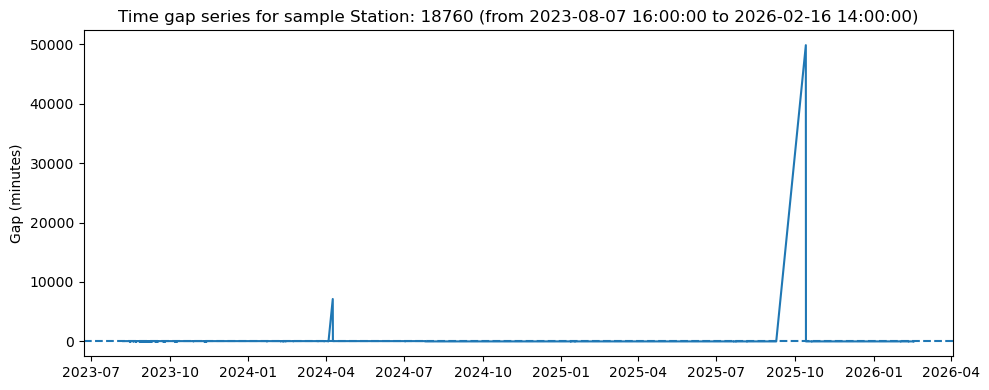

In [10]:
# OPTIONAL advanced visualization
sid= 18760  # choose station
dfk = stations_k[sid]

gaps = dfk.index.to_series().diff().dt.total_seconds()/60

plt.figure(figsize=(10,4))
plt.plot(gaps.index, gaps.values)
plt.axhline(60, linestyle="--")  # 1-hour threshold
plt.title(f"Time gap series for sample Station: {sid} (from 2023-08-07 16:00:00 to 2026-02-16 14:00:00)")
plt.ylabel("Gap (minutes)")
plt.tight_layout()
plt.show()

### “Time-gap analysis revealed significant data transmission interruptions across several stations, indicating periods of logger or communication downtime that may affect the continuity of environmental monitoring.

,StationId,variable,most_common_value,most_common_share,longest_constant_run,non_missing
71,18764,"Wind Speed,Average",0.0,1.000000,36063,36063
72,18764,"Wind Speed,Minimum",0.0,1.000000,36063,36063
73,18764,"Wind Speed,Maximum",0.0,1.000000,36063,36063
39,18761,"Wind Speed,Average",0.0,1.000000,19252,19252
40,18761,"Wind Speed,Minimum",0.0,1.000000,19252,19252
41,18761,"Wind Speed,Maximum",0.0,1.000000,19252,19252
74,18764,"Precipitation,Accumulation",0.0,0.999251,40532,82791
63,18763,"Precipitation,Accumulation",0.0,0.995317,43895,98860
31,18760,"Precipitation,Accumulation",0.0,0.995221,29984,85995
9,18758,"Precipitation,Accumulation",0.0,0.978052,2515,29843


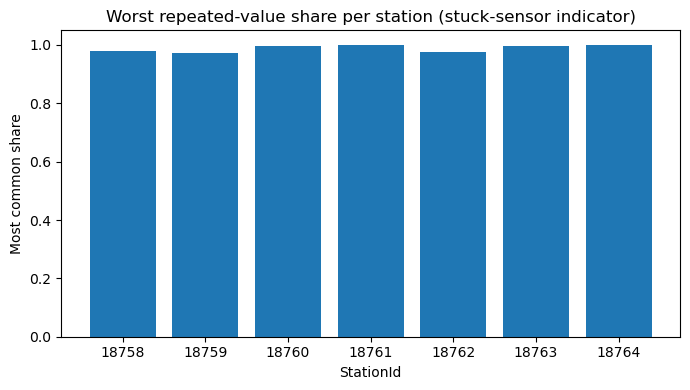

Saved: network_repeated_value_diagnosis.csv


In [12]:
# ==========================================================
# CELL 6 — Analysis 4: stuck sensors (most repeated share + longest run)
# ==========================================================
def longest_constant_run(series: pd.Series) -> int:
    s = series.dropna()
    if len(s) == 0:
        return 0
    groups = (s != s.shift()).cumsum()
    return int(s.groupby(groups).size().max())

rep_rows = []
for sid, dfk in stations_k.items():
    for col in dfk.columns:
        s = dfk[col].dropna()
        if len(s) < 20:
            continue
        vc = s.value_counts()
        top_val = vc.index[0]
        top_share = float(vc.iloc[0] / len(s))
        run = longest_constant_run(dfk[col])
        rep_rows.append([sid, col, top_val, top_share, run, int(len(s))])

rep = pd.DataFrame(rep_rows, columns=["StationId","variable","most_common_value","most_common_share","longest_constant_run","non_missing"])

# Show the MOST suspicious: high share + long runs
rep_susp = rep.sort_values(["most_common_share","longest_constant_run"], ascending=False)
display(rep_susp.head(30))

# Visualization: worst most_common_share per station
worst = rep.groupby("StationId")["most_common_share"].max().reset_index()
plt.figure(figsize=(7,4))
plt.bar(worst["StationId"].astype(str), worst["most_common_share"])
plt.title("Worst repeated-value share per station (stuck-sensor indicator)")
plt.xlabel("StationId")
plt.ylabel("Most common share")
plt.tight_layout()
plt.show()

rep.to_csv("network_repeated_value_diagnosis.csv", index=False)
print("Saved: network_repeated_value_diagnosis.csv")

### Repeated-value analysis revealed that the wind speed sensor at Station 18761 and 18764 remained constant at zero throughout the observation period, strongly indicating a sensor or channel malfunction.

### Station 18761 and 18764— Wind Speed Average stuck at 0 (share = 1.000)

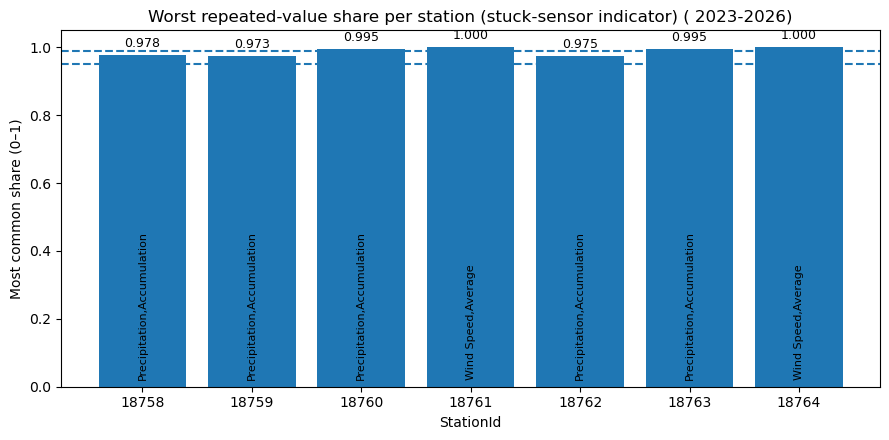

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# rep should already exist from Analysis 4
# columns expected: StationId, variable, most_common_share, longest_constant_run
# If not, tell me and I’ll paste the full cell to rebuild `rep`.

# 1) pick the worst variable per station
worst = (rep.sort_values(["StationId","most_common_share","longest_constant_run"], ascending=[True, False, False])
           .groupby("StationId")
           .head(1)
           .copy())

worst = worst.sort_values("StationId")
x = worst["StationId"].astype(str).tolist()
y = worst["most_common_share"].values
labels = worst["variable"].astype(str).tolist()

plt.figure(figsize=(9,4.5))
bars = plt.bar(x, y)

plt.title("Worst repeated-value share per station (stuck-sensor indicator) ( 2023-2026)")
plt.xlabel("StationId")
plt.ylabel("Most common share (0–1)")
plt.ylim(0, 1.05)

# Useful thresholds
plt.axhline(0.95, linestyle="--")  # suspicious
plt.axhline(0.99, linestyle="--")  # very suspicious

# annotate value + variable name
for b, share, var in zip(bars, y, labels):
    plt.text(b.get_x() + b.get_width()/2, share + 0.015, f"{share:.3f}",
             ha="center", va="bottom", fontsize=9)
    plt.text(b.get_x() + b.get_width()/2, 0.02, var,
             ha="center", va="bottom", fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# Most common share	Interpretation
### < 0.5	normal
### 0.5–0.8	watch
### 0.8–0.95	suspicious
### > 0.95	🚨 likely stuck
### = 1.0	🚨🚨 almost certainly stuck

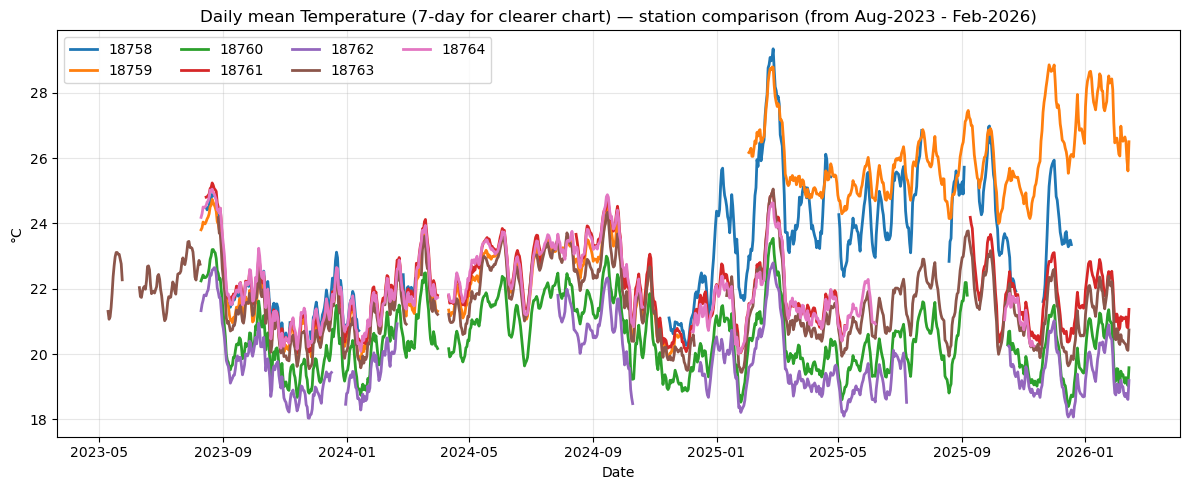

In [19]:
# ==========================================================
# CLEARER VERSION — 7-day smoothed temperature comparison
# ==========================================================

VAR_TEMP = "Temperature,Average"

plt.figure(figsize=(12,5))

for sid, dfk in stations_k.items():
    if VAR_TEMP in dfk.columns:
        series = dfk[VAR_TEMP].resample("D").mean()

        # ⭐ KEY IMPROVEMENT: smoothing
        smooth = series.rolling(7, center=True).mean()

        plt.plot(smooth.index, smooth.values, label=str(sid), linewidth=2)

plt.title("Daily mean Temperature (7-day for clearer chart) — station comparison (from Aug-2023 - Feb-2026)")
plt.xlabel("Date")
plt.ylabel("°C")
plt.legend(ncol=4)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ==========================================================
# Correlation Analysis — Step 1: build aligned daily table
# ==========================================================

VAR = "Temperature,Average"

daily_dict = {}

for sid, dfk in stations_k.items():
    if VAR in dfk.columns:
        daily_series = dfk[VAR].resample("D").mean()
        daily_dict[str(sid)] = daily_series

daily_temp = pd.DataFrame(daily_dict)

# Drop days where all stations missing
daily_temp = daily_temp.dropna(how="all")

print("Shape:", daily_temp.shape)
display(daily_temp.head())

Shape: (1003, 7)


,18758,18759,18760,18761,18762,18763,18764
datetime,,,,,,,
2023-05-07,NaN,NaN,NaN,NaN,NaN,24.192857,NaN
2023-05-08,NaN,NaN,NaN,NaN,NaN,22.633333,NaN
2023-05-09,NaN,NaN,NaN,NaN,NaN,21.029167,NaN
2023-05-10,NaN,NaN,NaN,NaN,NaN,19.350000,NaN
2023-05-11,NaN,NaN,NaN,NaN,NaN,19.258333,NaN


In [21]:
# ==========================================================
# Step 2: correlation matrix
# ==========================================================

corr_matrix = daily_temp.corr()

print("Temperature correlation matrix:")
display(corr_matrix)

Temperature correlation matrix:


,18758,18759,18760,18761,18762,18763,18764
18758,1.000000,0.784397,0.732573,0.757223,0.694358,0.762404,0.708586
18759,0.784397,1.000000,0.400738,0.449980,0.361345,0.447705,0.480717
18760,0.732573,0.400738,1.000000,0.949624,0.949471,0.950532,0.952939
18761,0.757223,0.449980,0.949624,1.000000,0.927760,0.943723,0.973001
18762,0.694358,0.361345,0.949471,0.927760,1.000000,0.938826,0.908713
18763,0.762404,0.447705,0.950532,0.943723,0.938826,1.000000,0.924377
18764,0.708586,0.480717,0.952939,0.973001,0.908713,0.924377,1.000000


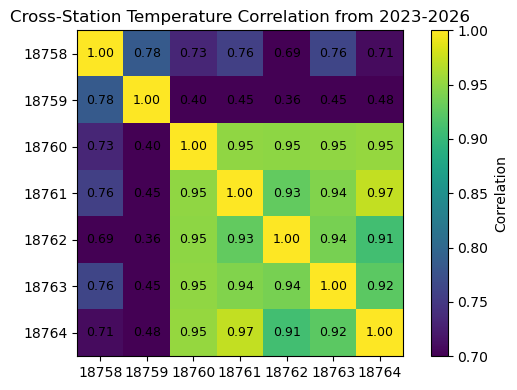

In [36]:
# ==========================================================
# Step 3: correlation heatmap (matplotlib only)
# ==========================================================

plt.figure(figsize=(6,4))

plt.imshow(corr_matrix.values, vmin=0.7, vmax=1.0)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

# add numbers inside cells
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(j, i, f"{corr_matrix.values[i,j]:.2f}",
                 ha="center", va="center", fontsize=9)

plt.colorbar(label="Correlation")
plt.title("Cross-Station Temperature Correlation from 2023-2026")
plt.tight_layout()
plt.show()

In [23]:
# ==========================================================
# Step 4: station consistency score
# ==========================================================

# mean correlation per station (excluding self-correlation)
mean_corr = (corr_matrix.replace(1.0, np.nan)
             .mean()
             .sort_values())

display(mean_corr.to_frame("mean_correlation_with_others"))

worst_station = mean_corr.idxmin()
best_station = mean_corr.idxmax()

print("⚠️ Most inconsistent station:", worst_station)
print("✅ Most consistent station:", best_station)

,mean_correlation_with_others
18759,0.487480
18758,0.739924
18762,0.796746
18760,0.822646
18764,0.824722
18763,0.827928
18761,0.833552


⚠️ Most inconsistent station: 18759
✅ Most consistent station: 18761


In [24]:
# ==========================================================
# Cross-station precipitation — Step 1: build daily totals
# ==========================================================

VAR = "Precipitation,Accumulation"  # change if your column name differs

daily_rain = {}

for sid, dfk in stations_k.items():
    if VAR in dfk.columns:
        daily_series = dfk[VAR].resample("D").sum()
        daily_rain[str(sid)] = daily_series

daily_rain = pd.DataFrame(daily_rain)

# drop days where all stations missing
daily_rain = daily_rain.dropna(how="all")

print("Shape:", daily_rain.shape)
display(daily_rain.head())

Shape: (1085, 7)


,18758,18759,18760,18761,18762,18763,18764
datetime,,,,,,,
2023-02-28,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-03-01,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-03-02,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-03-03,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-03-04,NaN,NaN,NaN,NaN,NaN,0.0,NaN


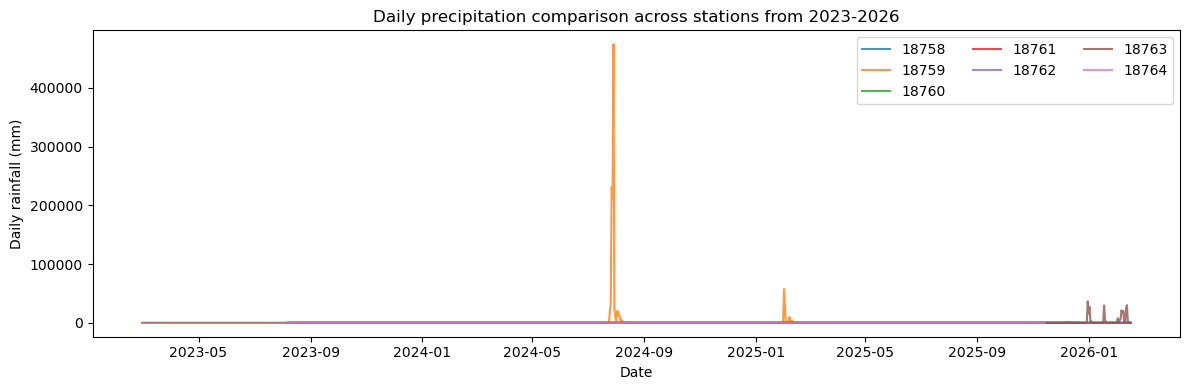

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

for col in daily_rain.columns:
    plt.plot(daily_rain.index, daily_rain[col], label=col, alpha=0.8)

plt.title("Daily precipitation comparison across stations from 2023-2026")
plt.xlabel("Date")
plt.ylabel("Daily rainfall (mm)")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

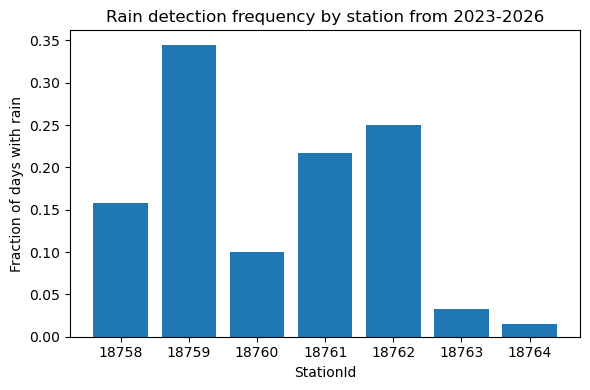

,rain_day_fraction
18758,0.158525
18759,0.344700
18760,0.100461
18761,0.216590
18762,0.249770
18763,0.032258
18764,0.014747


In [33]:
# ==========================================================
# Rain-day percentage per station
# ==========================================================

rain_days_pct = (daily_rain > 0).mean().sort_index()

plt.figure(figsize=(6,4))
plt.bar(rain_days_pct.index, rain_days_pct.values)
plt.title("Rain detection frequency by station from 2023-2026")
plt.xlabel("StationId")
plt.ylabel("Fraction of days with rain")
plt.tight_layout()
plt.show()

display(rain_days_pct.to_frame("rain_day_fraction"))

### FINAL CONCLUSION RANKING

In [27]:
# ==========================================================
# Station Health — Step 1: compute QC metrics
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# QC physical range rules (define once)
# ==========================================================

rules = {
    "Temperature,Average": (-10, 45),
    "Temperature,Minimum": (-10, 45),
    "Temperature,Maximum": (-10, 45),
    "Humidity,Avarage": (0, 100),
    "Humidity,Minimum": (0, 100),
    "Humidity,Maximum": (0, 100),
    "Wind Speed,Average": (0, 60),
    "Wind Speed,Minimum": (0, 60),
    "Wind Speed,Maximum": (0, 60),
    "Precipitation,Accumulation": (0, 500),
    "Global solar radiation,Average": (0, 1400),
}

health_rows = []

for sid, dfk in stations_k.items():

    row = {"StationId": sid}

    # -----------------------------
    # 1) Completeness
    # -----------------------------
    completeness = dfk.notna().mean().mean()
    row["completeness"] = completeness

    # -----------------------------
    # 2) Out-of-range rate
    # -----------------------------
    oor_total = 0
    oor_count = 0

    for col, (lo, hi) in rules.items():
        if col in dfk.columns:
            s = dfk[col].dropna()
            if len(s) > 0:
                oor = ((s < lo) | (s > hi)).mean()
                oor_total += oor
                oor_count += 1

    row["out_of_range_rate"] = oor_total / oor_count if oor_count else 0

    # -----------------------------
    # 3) Temperature ordering violations
    # -----------------------------
    tcols = ["Temperature,Minimum","Temperature,Average","Temperature,Maximum"]
    if all(c in dfk.columns for c in tcols):
        mask = ~(
            (dfk[tcols[0]] <= dfk[tcols[1]]) &
            (dfk[tcols[1]] <= dfk[tcols[2]])
        )
        row["temp_order_rate"] = mask.mean()
    else:
        row["temp_order_rate"] = 0

    # -----------------------------
    # 4) Time gaps
    # -----------------------------
    diffs = dfk.index.to_series().diff().dt.total_seconds()/60
    row["max_gap_min"] = diffs.max()

    # normalize later
    # -----------------------------
    # 5) Stuck sensor indicator
    # -----------------------------
    worst_share = 0

    for c in dfk.columns:
        s = dfk[c].dropna()
        if len(s) > 0:
            share = s.value_counts(normalize=True).iloc[0]
            worst_share = max(worst_share, share)

    row["worst_repeated_share"] = worst_share

    health_rows.append(row)

health_df = pd.DataFrame(health_rows).sort_values("StationId")
display(health_df)

,StationId,completeness,out_of_range_rate,temp_order_rate,max_gap_min,worst_repeated_share
0,18758,0.984586,0.000458,0.000000,352490.0,0.978052
1,18759,0.994799,0.002014,0.349790,38737.0,0.972914
2,18760,0.999962,0.018149,0.044162,49820.0,0.995221
3,18761,0.999912,0.000000,0.000000,168720.0,1.000000
4,18762,0.999993,0.000273,0.163964,220300.0,0.975178
5,18763,0.999740,0.000505,0.149549,94830.0,0.995317
6,18764,0.755158,0.000000,0.435484,175510.0,1.000000


In [28]:
# ==========================================================
# Step 2: normalize metrics
# ==========================================================

health_df["gap_norm"] = (
    np.log1p(health_df["max_gap_min"]) /
    np.log1p(health_df["max_gap_min"].max())
)

health_df["missing_penalty"] = 1 - health_df["completeness"]

display(health_df)

,StationId,completeness,out_of_range_rate,temp_order_rate,max_gap_min,worst_repeated_share,gap_norm,missing_penalty
0,18758,0.984586,0.000458,0.000000,352490.0,0.978052,1.000000,0.015414
1,18759,0.994799,0.002014,0.349790,38737.0,0.972914,0.827116,0.005201
2,18760,0.999962,0.018149,0.044162,49820.0,0.995221,0.846816,0.000038
3,18761,0.999912,0.000000,0.000000,168720.0,1.000000,0.942317,0.000088
4,18762,0.999993,0.000273,0.163964,220300.0,0.975178,0.963201,0.000007
5,18763,0.999740,0.000505,0.149549,94830.0,0.995317,0.897209,0.000260
6,18764,0.755158,0.000000,0.435484,175510.0,1.000000,0.945406,0.244842


In [29]:
# ==========================================================
# Step 3: final health score
# ==========================================================

health_df["health_score"] = 1 - (
      0.30 * health_df["out_of_range_rate"]
    + 0.30 * health_df["temp_order_rate"]
    + 0.15 * health_df["missing_penalty"]
    + 0.15 * health_df["gap_norm"]
    + 0.10 * health_df["worst_repeated_share"]
)

health_df = health_df.sort_values("health_score", ascending=False)

display(health_df[[
    "StationId",
    "health_score",
    "completeness",
    "out_of_range_rate",
    "temp_order_rate",
    "max_gap_min",
    "worst_repeated_share"
]])

,StationId,health_score,completeness,out_of_range_rate,temp_order_rate,max_gap_min,worst_repeated_share
3,18761,0.758639,0.999912,0.000000,0.000000,168720.0,1.000000
2,18760,0.754757,0.999962,0.018149,0.044162,49820.0,0.995221
0,18758,0.749745,0.984586,0.000458,0.000000,352490.0,0.978052
5,18763,0.720832,0.999740,0.000505,0.149549,94830.0,0.995317
4,18762,0.708730,0.999993,0.000273,0.163964,220300.0,0.975178
1,18759,0.672320,0.994799,0.002014,0.349790,38737.0,0.972914
6,18764,0.590818,0.755158,0.000000,0.435484,175510.0,1.000000


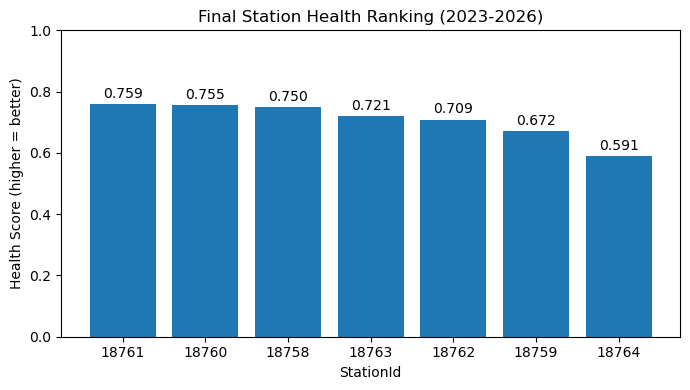

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.bar(
    health_df["StationId"].astype(str),
    health_df["health_score"]
)

plt.title("Final Station Health Ranking (2023-2026)")
plt.xlabel("StationId")
plt.ylabel("Health Score (higher = better)")
plt.ylim(0, 1)

for i, v in enumerate(health_df["health_score"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

# Interpretation of results
## Score	Meaning
### > 0.90	excellent
### 0.80–0.90	good
### 0.70–0.80	monitor
### 0.60–0.70	warning
### < 0.60	🚨 needs maintenance

### 